In [ ]:
import pandas as pd
import os
import glob
import re

folder_path = "/content/"
all_files = glob.glob(os.path.join(folder_path, "filtered_*_*.csv"))

In [ ]:
env_rows = {
    1: [7, 13, 19, 25, 31, 37, 43, 49, 55, 61],
    2: [67, 73, 79, 85, 91, 97, 103, 109, 115, 121],
    3: [127, 133, 139, 145, 151, 157, 163, 169, 175, 181],
    4: [187, 193, 199, 205, 211, 217, 223, 229, 235, 241]
    }

final_results = []


In [ ]:
for file in all_files:
    # Extract participant ID
    match = re.search(r"filtered_(\d+)_", os.path.basename(file))

    participant_id = int(match.group(1))

    df = pd.read_csv(file)

    env_averages = {}
    all_stress_values = []

    for env, rows in env_rows.items():
        valid_rows = [r for r in rows if r < len(df)]
        stress_vals = pd.to_numeric(df.loc[valid_rows, "stressSlider.response"], errors='coerce')
        avg = stress_vals.mean()
        env_averages[env] = avg
        all_stress_values.extend(stress_vals.dropna().tolist())

    # Prepare final output row
    final_results.append({
        "participant_id": participant_id,
        "total_score": df.iloc[240]['total_score'],
        "stress_avg_env1": float(env_averages.get(1)),
        "stress_avg_env2": float(env_averages.get(2)),
        "stress_avg_env3": float(env_averages.get(3)),
        "stress_avg_env4": float(env_averages.get(4))
    })



In [ ]:
# Round numeric columns to 4 decimal places (or as needed)
final_df[["total_score", "stress_avg_env1", "stress_avg_env2", "stress_avg_env3", "stress_avg_env4"]] = (
    final_df[["total_score", "stress_avg_env1", "stress_avg_env2", "stress_avg_env3", "stress_avg_env4"]]
    .apply(pd.to_numeric, errors='coerce')
    .round(4)
)


In [ ]:
final_df = pd.DataFrame(final_results)
final_df = final_df.sort_values(by="participant_id")

# Save to CSV
final_df.to_csv("avg_stress.csv", index=False)

print("Saved to 'average_stress_by_participant.csv'")

Saved to 'average_stress_by_participant.csv'


In [ ]:
def filter_dataframe_rows(df, start_row, end_row, skip_rows=None):
    mask = pd.Series(False, index=df.index)
    mask.iloc[start_row:end_row + 1] = True

    mask[skip_rows] = False

    filtered_df = df.loc[mask[mask].index].copy()
    return filtered_df

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define trial row ranges for each environment
env_ranges = {
    1: (2, 61),
    2: (62, 121),
    3: (122, 181),
    4: (182, 241)
}

results = []


In [ ]:
for file in all_files:
    # Extract participant ID
    match = re.search(r"filtered_(\d+)_", os.path.basename(file))

    participant_id = int(match.group(1))

    df = pd.read_csv(file)

    i=1

    participant_result = []

    for env, (start, end) in env_ranges.items():
        env_trials = filter_dataframe_rows(df, start, end, env_rows[i])
        i = i + 1

        island_counts = env_trials['best_island'].value_counts()

        # Find the most and least frequent islands
        most_rewarding_island = island_counts.idxmax()
        least_rewarding_island = island_counts.idxmin()

        # Visit counts
        visit_counts = env_trials["chosen_image"].value_counts()
        visits_most = visit_counts.get(most, 0)
        visits_least = visit_counts.get(least, 0)

        participant_result.append({
            f"most_rewarding_env{env}": most,
            f"visits_most_rewarding_env{env}": visits_most,
            f"least_rewarding_env{env}": least,
            f"visits_least_rewarding_env{env}": visits_least
        })

    merged_participant_result = {}

    merged_participant_result.update({"participant_id": participant_id})

    for i in participant_result:
        merged_participant_result.update(i)

    results.append(merged_participant_result)




In [ ]:
visited_most_least = pd.DataFrame(results)
visited_most_least = visited_most_least.sort_values(by="participant_id")

visited_most_least.to_csv("visited_most_least.csv", index=False)

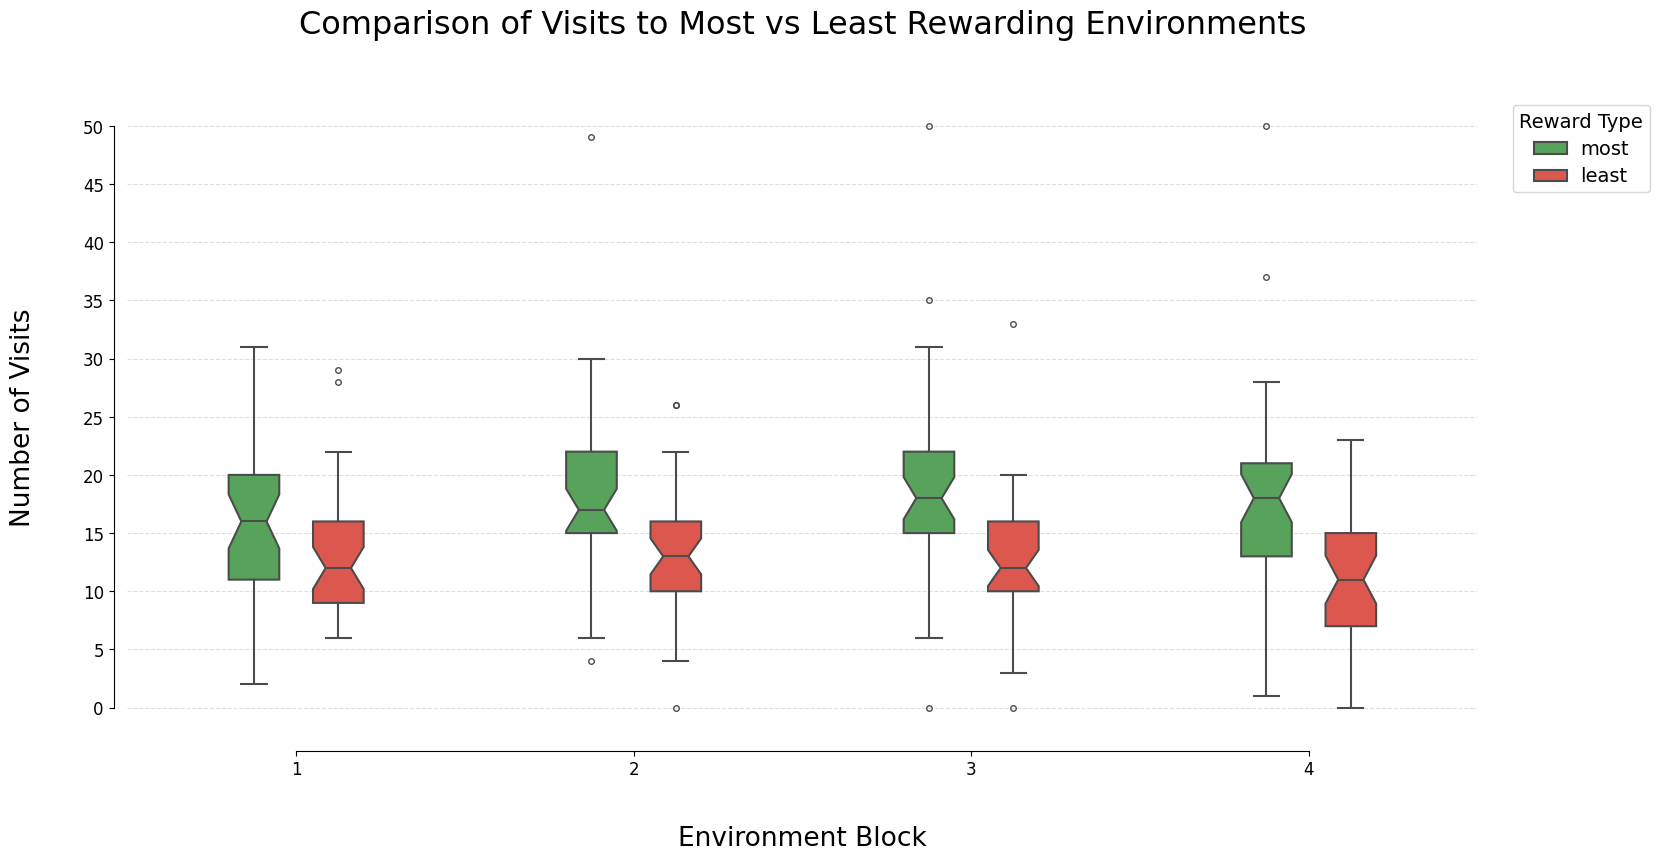

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('visited_most_least.csv')

# Reshape to long format
data = pd.melt(df,
               id_vars=['participant_id'],
               value_vars=[f'visits_most_rewarding_env{i}' for i in range(1,5)] +
                         [f'visits_least_rewarding_env{i}' for i in range(1,5)],
               var_name='variable',
               value_name='visits')

# Extract environment and reward type from variable names
data['environment'] = data['variable'].str.extract('env(\d)')
data['reward_type'] = data['variable'].str.extract('(most|least)_rewarding')

# Clean up
data = data.drop('variable', axis=1)

# Create the notch plot with increased within-group spacing
plt.figure(figsize=(18, 8))
ax = sns.boxplot(data=data, x='environment', y='visits', hue='reward_type',
                notch=True, palette={'most': '#4caf50', 'least': '#f44336'},
                width=0.5, linewidth=1.5, fliersize=4,
                dodge=True, gap=0.4)

# Title and labels with larger fonts
plt.title('Comparison of Visits to Most vs Least Rewarding Environments\n',
          fontsize=23, pad=20)
plt.xlabel('\nEnvironment Block', fontsize=19, labelpad=12)
plt.ylabel('Number of Visits\n', fontsize=19, labelpad=12)

# Legend with larger font
legend = plt.legend(title='Reward Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.setp(legend.get_title(), fontsize=14)
plt.setp(legend.get_texts(), fontsize=14)

# Adjust spacing
plt.subplots_adjust(left=0.1, right=0.85, top=0.9, bottom=0.1)
sns.despine(offset=10, trim=True)

# Increase tick label sizes
ax.tick_params(axis='both', which='major', labelsize=12)

# Customize y-axis ticks
ax.yaxis.set_major_locator(plt.MaxNLocator(12))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Increase font size for all text elements
plt.rcParams.update({'font.size': 12})

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

def calculate_exploration_metrics(participant_df, participant_id):
    # df = participant_df.dropna(subset=['chosen_image', 'best_island']).copy()
    df['best_image'] = df['best_island'].map({0: 'image_1', 1: 'image_2', 2: 'image_3'})

    # Basic metrics
    df['is_exploration'] = df['chosen_image'] != df['best_image']
    df['switched'] = df['chosen_image'] != df['chosen_image'].shift(1)
    df['prev_reward'] = df['delta_score'].shift(1) > 0
    df['stay'] = df['chosen_image'] == df['chosen_image'].shift(1)

    # Initialize metrics dictionary
    metrics = {
        'participant_id': participant_id,
        'total_trials': len(df)
    }

    # Environment-Specific Directed Exploration Rates
    # -------------------------------------------------
    directed_metrics = {}
    i = 1

    for env, (start, end) in env_ranges.items():
        print(start)
        env_trials = filter_dataframe_rows(df, start, end, env_rows[i])
        i = i + 1

        # Calculate strategic switches after negative outcomes
        env_trials['after_negative'] = (env_trials['delta_score'].shift(1) < 0)
        env_trials['strategic_switch'] = (env_trials['after_negative'] &
                                          env_trials['switched'])

        # Directed exploration rate = strategic switches / opportunities
        negative_count = env_trials['after_negative'].sum()
        strategic_count = env_trials['strategic_switch'].sum()

        directed_rate = (strategic_count / negative_count
                          if negative_count > 0 else np.nan)

        # Store metrics
        directed_metrics[f'directed_rate_env{env}'] = directed_rate
        directed_metrics[f'explore_rate_env{env}'] = env_trials['is_exploration'].mean()
        directed_metrics[f'negative_opportunities_env{env}'] = negative_count

    metrics.update(directed_metrics)

    # Random Exploration Calculation (Global)
    # -----------------------------------------
    random_metrics = {}
    i = 1

    for env, (start, end) in env_ranges.items():
        print(start)
        env_trials = filter_dataframe_rows(df, start, end, env_rows[i])
        i = i + 1

        # Prepare features (reward history and context)
        X = env_trials[['delta_score', 'total_score']].fillna(0)
        y = env_trials['is_exploration'].astype(int)

        # 1. Random Exploration Score (1 - model accuracy)
        try:
            model = LogisticRegression(max_iter=1000)
            model.fit(X, y)
            accuracy = model.score(X, y)
            random_score = 1 - accuracy
        except:
            random_score = np.nan

        # 2. Unexplained variance (entropy)
        explore_prob = y.mean()
        max_entropy = - (explore_prob * np.log2(explore_prob + 1e-10) +
                        (1-explore_prob) * np.log2(1-explore_prob + 1e-10))
        residual_entropy = max_entropy * random_score

        # Store metrics
        random_metrics.update({
            f'random_score_env{env}': random_score,
            f'unexplained_variance_env{env}': residual_entropy,
            f'baseline_explore_env{env}': explore_prob
        })

    metrics.update(random_metrics)


    # Global Metrics (same as before)
    # --------------------------------
    global_metrics = {
        'exploration_rate': df['is_exploration'].mean(),
        'switching_rate': df['switched'].mean(),
        'win_stay_rate': df[df['prev_reward']]['stay'].mean(),
        'lose_shift_rate': 1 - df[~df['prev_reward']]['stay'].mean()
    }
    metrics.update(global_metrics)

    return metrics

In [ ]:
explore_exploit_result = []

for file in all_files:
    # Extract participant ID
    match = re.search(r"filtered_(\d+)_", os.path.basename(file))

    participant_id = int(match.group(1))

    df = pd.read_csv(file)

    participant_metrics = calculate_exploration_metrics(df, participant_id)

    explore_exploit_result.append(participant_metrics)



In [ ]:
explore_exploit_results = pd.DataFrame(explore_exploit_result)
explore_exploit_results = explore_exploit_results.sort_values(by="participant_id")

explore_exploit_results.to_csv("explore_exploit_results.csv", index=False)

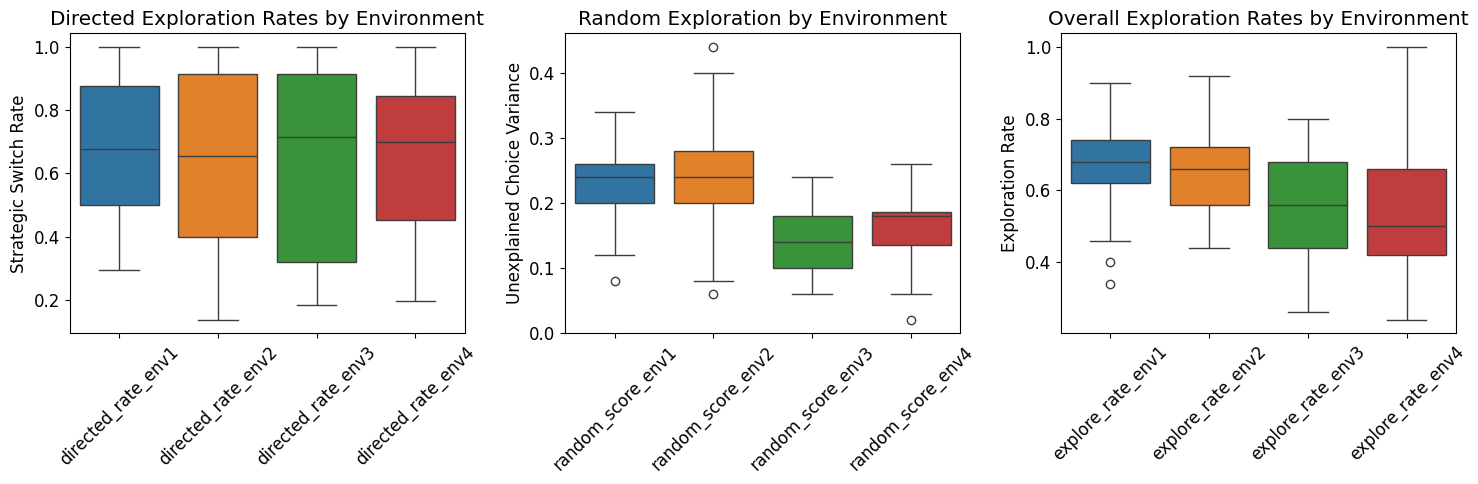

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_environment_comparison(results_df):
    """Compare exploration metrics across environments"""
    plt.figure(figsize=(15, 5))

    # Directed Exploration Rates
    plt.subplot(1, 3, 1)
    sns.boxplot(data=results_df.filter(regex='directed_rate_env'))
    plt.title('Directed Exploration Rates by Environment')
    plt.ylabel('Strategic Switch Rate')
    plt.xticks(rotation=45)

    # Random Exploration Scores
    plt.subplot(1, 3, 2)
    sns.boxplot(data=results_df.filter(regex='random_score_env'))
    plt.title('Random Exploration by Environment')
    plt.ylabel('Unexplained Choice Variance')
    plt.xticks(rotation=45)

    # Exploration Rates
    plt.subplot(1, 3, 3)
    sns.boxplot(data=results_df.filter(regex='explore_rate_env'))
    plt.title('Overall Exploration Rates by Environment')
    plt.ylabel('Exploration Rate')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

plot_environment_comparison(explore_exploit_results)

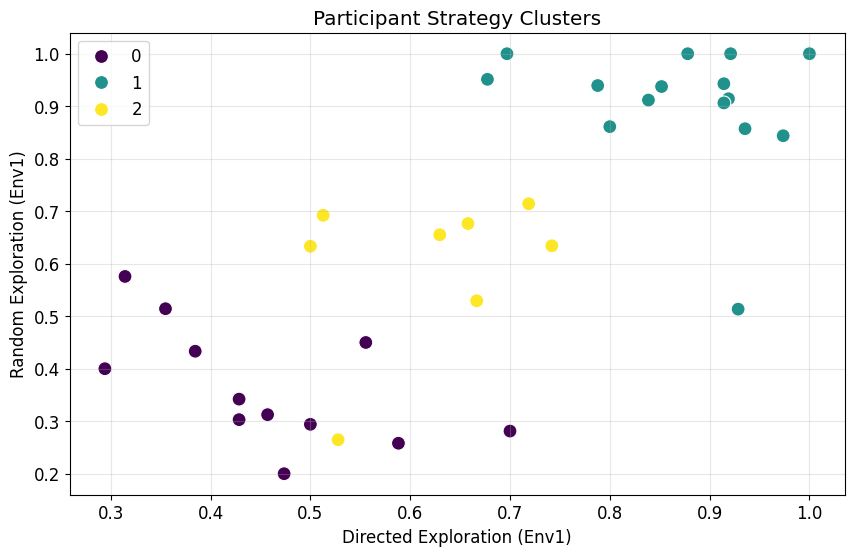

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def plot_strategy_clusters(results_df):
    """Cluster participants by exploration strategies"""
    # Prepare features
    features = results_df.filter(regex='directed_rate_env|random_score_env')
    features = features.dropna()
    scaled = StandardScaler().fit_transform(features)

    # Cluster
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(scaled)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=features.iloc[:, 0],
        y=features.iloc[:, 1],
        hue=clusters,
        palette='viridis',
        s=100
    )
    plt.title('Participant Strategy Clusters')
    plt.xlabel('Directed Exploration (Env1)')
    plt.ylabel('Random Exploration (Env1)')
    plt.grid(alpha=0.3)
    plt.show()

plot_strategy_clusters(explore_exploit_results)

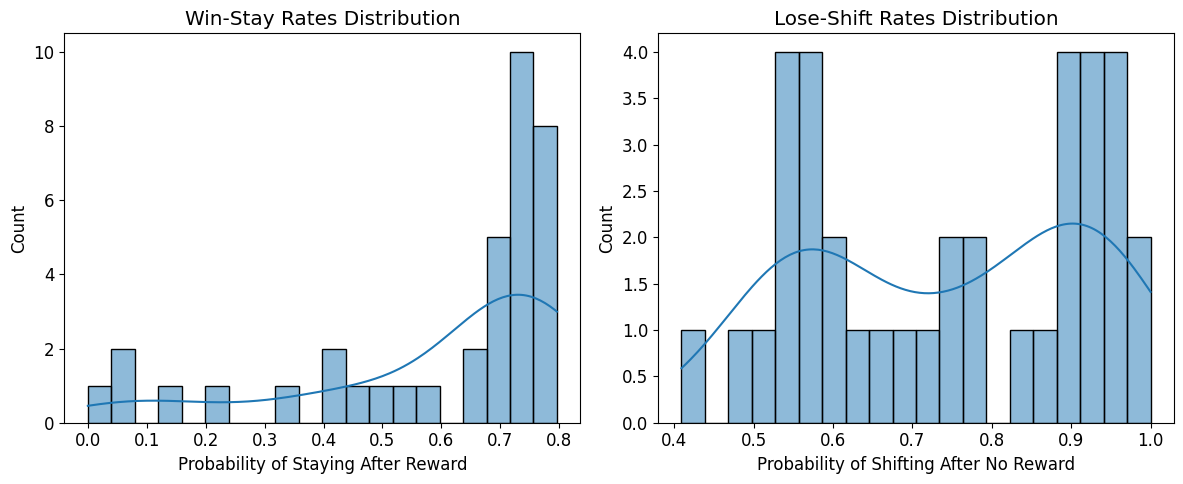

In [ ]:
def plot_win_stay_lose_shift(results_df):
    """Compare behavioral adaptation patterns"""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(data=results_df, x='win_stay_rate', bins=20, kde=True)
    plt.title('Win-Stay Rates Distribution')
    plt.xlabel('Probability of Staying After Reward')

    plt.subplot(1, 2, 2)
    sns.histplot(data=results_df, x='lose_shift_rate', bins=20, kde=True)
    plt.title('Lose-Shift Rates Distribution')
    plt.xlabel('Probability of Shifting After No Reward')

    plt.tight_layout()
    plt.show()

plot_win_stay_lose_shift(explore_exploit_results)

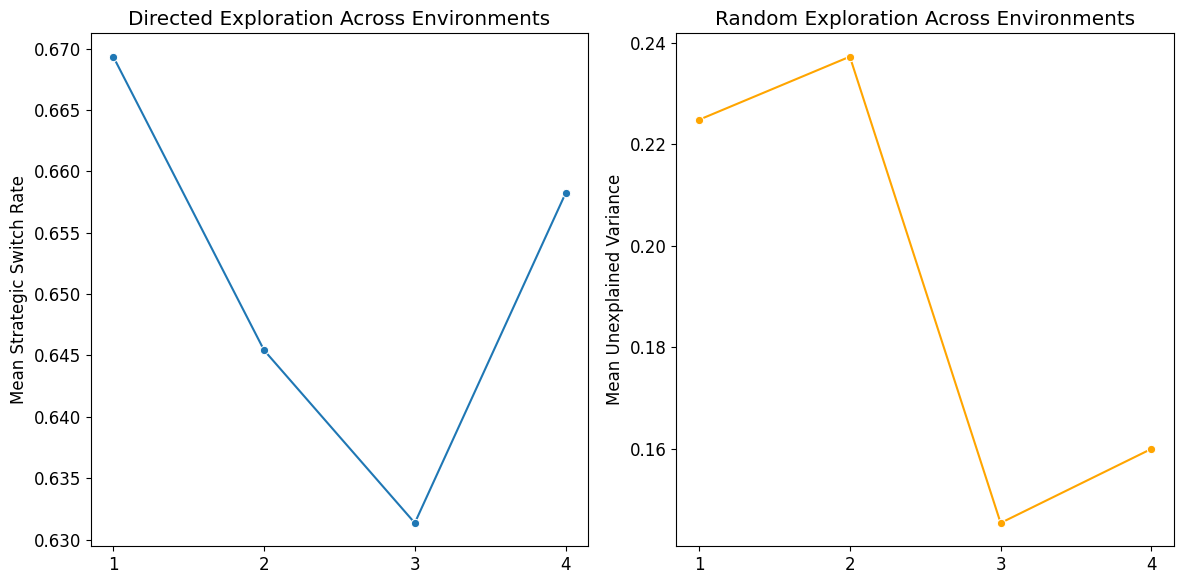

In [ ]:
def plot_environment_transitions(results_df):
    """How metrics change across environment transitions"""
    env_order = ['1', '2', '3', '4']

    plt.figure(figsize=(12, 6))

    # Directed Exploration
    plt.subplot(1, 2, 1)
    directed_data = [results_df[f'directed_rate_env{env}'].mean() for env in env_order]
    sns.lineplot(x=env_order, y=directed_data, marker='o')
    plt.title('Directed Exploration Across Environments')
    plt.ylabel('Mean Strategic Switch Rate')

    # Random Exploration
    plt.subplot(1, 2, 2)
    random_data = [results_df[f'random_score_env{env}'].mean() for env in env_order]
    sns.lineplot(x=env_order, y=random_data, marker='o', color='orange')
    plt.title('Random Exploration Across Environments')
    plt.ylabel('Mean Unexplained Variance')

    plt.tight_layout()
    plt.show()

plot_environment_transitions(explore_exploit_results)

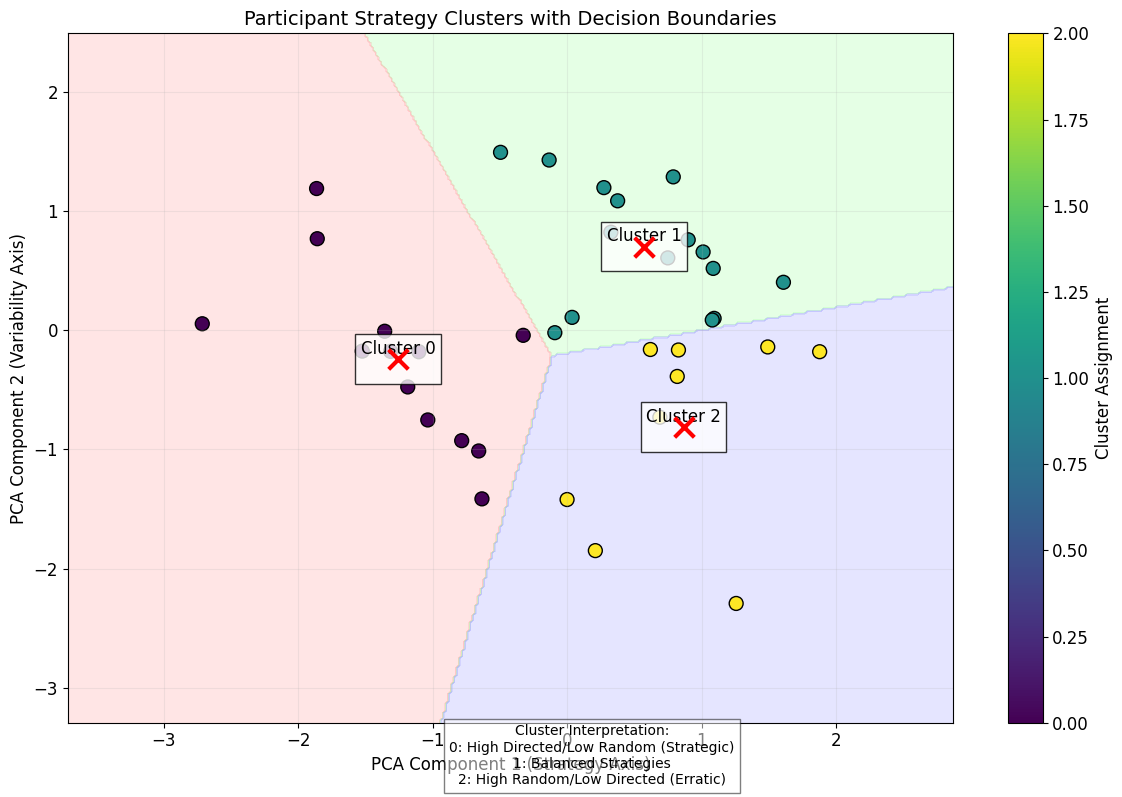

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

def plot_enhanced_strategy_clusters(results_df, n_clusters=3):
    """Cluster participants with decision boundaries"""
    # Prepare features (using mean across environments for simplicity)
    features = pd.DataFrame({
        'directed': results_df.filter(regex='directed_rate_env').mean(axis=1),
        'random': results_df.filter(regex='random_score_env').mean(axis=1)
    }).dropna()

    # Standardize and reduce dimensions
    scaled = StandardScaler().fit_transform(features)
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(scaled)

    # Cluster in PCA space
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(principal_components)

    # Create meshgrid for decision boundaries
    h = 0.02  # Step size
    x_min, x_max = principal_components[:, 0].min() - 1, principal_components[:, 0].max() + 1
    y_min, y_max = principal_components[:, 1].min() - 1, principal_components[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict clusters for meshgrid
    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(12, 8))

    # Decision boundaries
    cmap = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'][:n_clusters])
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    # Cluster points
    scatter = plt.scatter(
        principal_components[:, 0],
        principal_components[:, 1],
        c=clusters,
        cmap='viridis',
        s=100,
        edgecolor='k'
    )

    # Centroids
    centers = kmeans.cluster_centers_
    plt.scatter(
        centers[:, 0],
        centers[:, 1],
        marker='x',
        s=200,
        linewidths=3,
        color='red',
        zorder=10
    )

    # Annotations
    for i, center in enumerate(centers):
        plt.text(
            center[0], center[1],
            f'Cluster {i}\n',
            fontsize=12,
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.8))

    plt.title('Participant Strategy Clusters with Decision Boundaries', fontsize=14)
    plt.xlabel('PCA Component 1 (Strategy Axis)', fontsize=12)
    plt.ylabel('PCA Component 2 (Variability Axis)', fontsize=12)
    plt.colorbar(scatter, label='Cluster Assignment')
    plt.grid(alpha=0.2)

    # Add cluster interpretation
    plt.figtext(0.5, 0.01,
                "Cluster Interpretation:\n"
                "0: High Directed/Low Random (Strategic)\n"
                "1: Balanced Strategies\n"
                "2: High Random/Low Directed (Erratic)",
                ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.show()

plot_enhanced_strategy_clusters(explore_exploit_results)

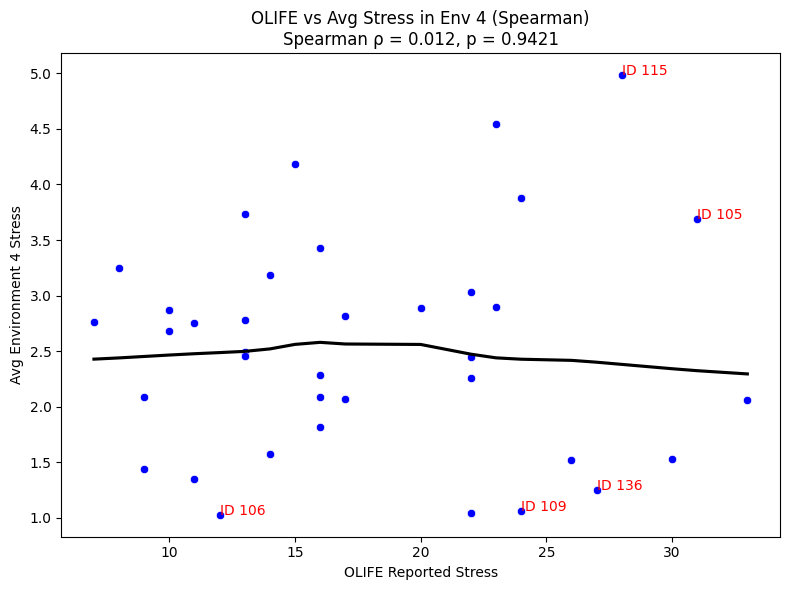

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import statsmodels.api as sm

# Load data
olife_df = pd.read_excel("O-LIFE Scores complete _1.xlsx")
stress_df = pd.read_excel("avg_stress_total_score.xlsx")

# Rename for consistency
olife_df = olife_df.rename(columns={"Participant ID": "ID", "total Score": "OLIFE_Stress"})
stress_df = stress_df.rename(columns={"participant_id": "ID"})

# Average environmental stress
env_cols = ["stress_avg_env1", "stress_avg_env2", "stress_avg_env3", "stress_avg_env4"]
# stress_df["Avg_Stress"] = stress_df[env_cols].mean(axis=1)
stress_df["Avg_Stress"] = stress_df[env_cols[3]]

# Merge
df = pd.merge(olife_df[["ID", "OLIFE_Stress"]], stress_df[["ID", "Avg_Stress"]], on="ID")

# Spearman correlation
rho, pval = spearmanr(df["OLIFE_Stress"], df["Avg_Stress"])

# Influence diagnostics using ranks
df["OLIFE_Stress_rank"] = df["OLIFE_Stress"].rank()
df["Avg_Stress_rank"] = df["Avg_Stress"].rank()
X_rank = sm.add_constant(df["OLIFE_Stress_rank"])
model_rank = sm.OLS(df["Avg_Stress_rank"], X_rank).fit()
cooks_rank = model_rank.get_influence().cooks_distance[0]

# Top 5 influential
df["Influence"] = cooks_rank
top_ids = df.sort_values("Influence", ascending=False).head(5)["ID"]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="OLIFE_Stress", y="Avg_Stress", color="blue")
sns.regplot(data=df, x="OLIFE_Stress", y="Avg_Stress", scatter=False, color="black", lowess=True)

for i, row in df[df["ID"].isin(top_ids)].iterrows():
    plt.annotate(f'ID {row["ID"]}', (row["OLIFE_Stress"], row["Avg_Stress"]), color='red')

plt.title(f"OLIFE vs Avg Stress in Env 4 (Spearman)\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
plt.xlabel("OLIFE Reported Stress")
plt.ylabel("Avg Environment 4 Stress")
plt.tight_layout()
plt.show()


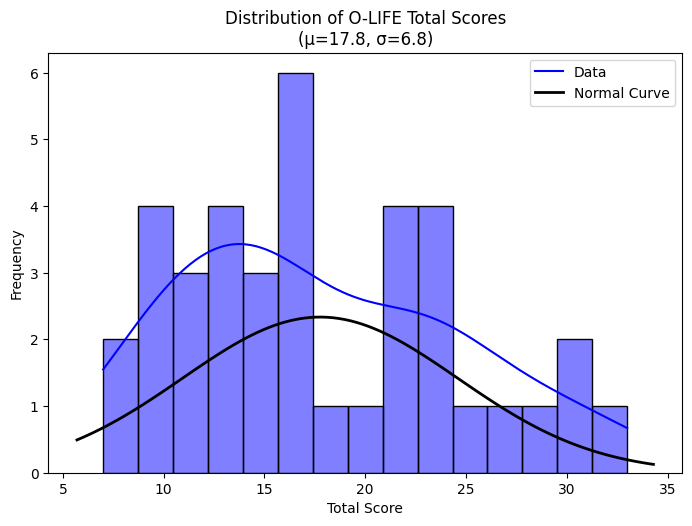

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# Load the data
olife_df = pd.read_excel("O-LIFE Scores complete _1.xlsx")

# Clean column names (remove spaces and standardize)
olife_df.columns = olife_df.columns.str.strip().str.replace(' ', '_')

# Create the distribution plots
plt.figure(figsize=(18, 12))

# Plot 1: Histogram with KDE and normal curve
plt.subplot(2, 2, 1)
sns.histplot(olife_df['total_Score'], kde=True, bins=15, color='blue', edgecolor='black')

# Add normal distribution curve
mu, std = norm.fit(olife_df['total_Score'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p*40, 'k', linewidth=2)  # Scaled to match histogram
plt.title(f'Distribution of O-LIFE Total Scores\n(μ={mu:.1f}, σ={std:.1f})')
plt.xlabel('Total Score')
plt.ylabel('Frequency')
plt.legend(['Data', 'Normal Curve'])

plt.show()